<a href="https://colab.research.google.com/github/ascot119-rgb/Alex-s-Projects/blob/main/SVM_and_SVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Kernel
Accuracy:  0.9649122807017544
Precision:  1.0
Recall:  0.9
F1 Score:  0.9473684210526316
Polynomial Kernel
Accuracy:  0.8947368421052632
Precision:  1.0
Recall:  0.7
F1 Score:  0.8235294117647058
RBF Kernel
Accuracy:  0.956140350877193
Precision:  1.0
Recall:  0.875
F1 Score:  0.9333333333333333
Sigmoid Kernel
Accuracy:  0.9385964912280702
Precision:  0.9714285714285714
Recall:  0.85
F1 Score:  0.9066666666666667


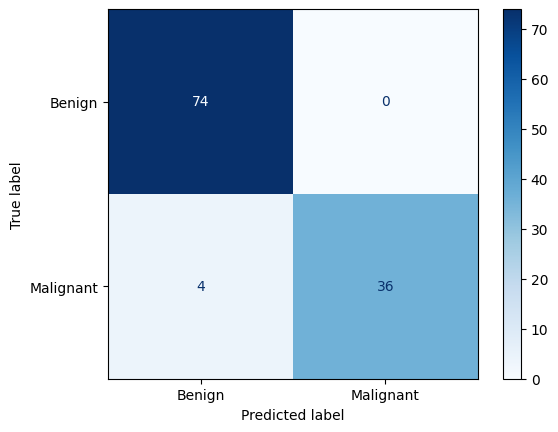

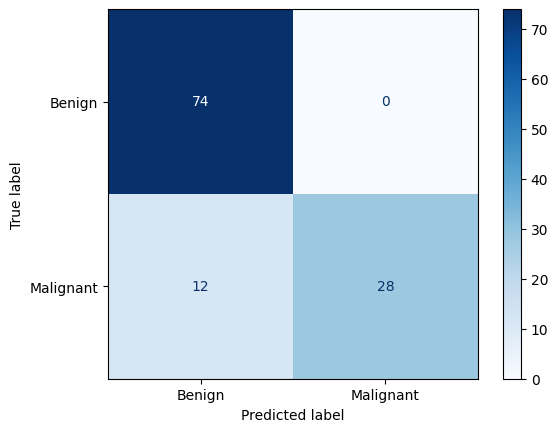

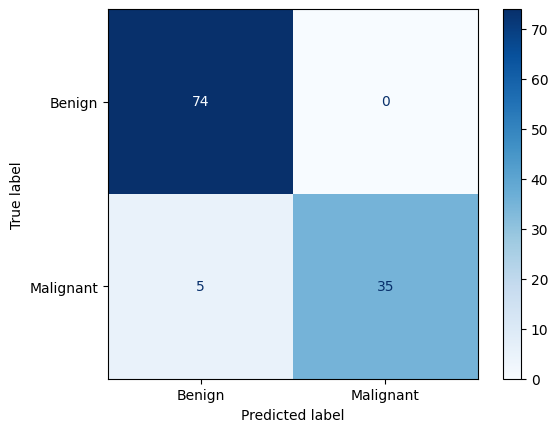

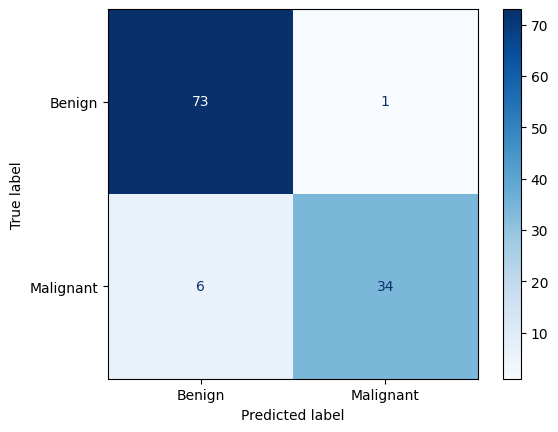

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random as rnd
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import ConfusionMatrixDisplay

def getprecision(predict, y):
  p = 0
  tp = 0
  for i in range(len(predict)):
    if predict[i] == 1:
      p += 1
    if predict[i] == 1 and y[i] == 1:
      tp += 1
  return tp/p

def getrecall(predict, y):
  rp = 0
  tp = 0
  for i in range(len(predict)):
    if y[i] == 1:
      rp += 1
    if predict[i] == 1 and y[i] == 1:
      tp += 1
  return tp/rp
def getf1(precision, recall):
  return 2*precision*recall/(precision+recall)

filepath = "/content/Cancer.csv"

df = pd.read_csv(filepath)

scaler_X = StandardScaler() # Scaler for input features


y = df.values[:, 1]
for i in range(len(y)):
  if y[i] == "M":
    y[i] = 1
  else:
    y[i] = 0
y=y.astype(int)

paramnames = df.columns.values[:]
params = np.zeros(len(df.values[0]))
inputdata = df.values[:, 2:-1]

inputdata = np.array(inputdata)
inputdata = scaler_X.fit_transform(inputdata) # Fit and transform input features


validation_indices = np.arange(0, len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)

index = np.arange(0, len(inputdata))

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

BOLD = '\033[1m'
END = '\033[0m'

result = svm.SVC(kernel="linear", C=1.0).fit(inputdata,y)
print(BOLD + "Linear Kernel" + END)
print("Accuracy: ", result.score(validationdata, validationy))
precision = getprecision(result.predict(validationdata), validationy)
recall = getrecall(result.predict(validationdata), validationy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", getf1(precision, recall))

class_names = ["Benign", "Malignant"]

disp = ConfusionMatrixDisplay.from_estimator(
      result,
      validationdata,
      validationy,
      display_labels=class_names,
      cmap=plt.cm.Blues,
      normalize=None,
 )

result = svm.SVC(kernel="poly", C=1.0).fit(inputdata,y)
print(BOLD + "Polynomial Kernel" + END)
print("Accuracy: ", result.score(validationdata, validationy))
precision = getprecision(result.predict(validationdata), validationy)
recall = getrecall(result.predict(validationdata), validationy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", getf1(precision, recall))

class_names = ["Benign", "Malignant"]

disp = ConfusionMatrixDisplay.from_estimator(
      result,
      validationdata,
      validationy,
      display_labels=class_names,
      cmap=plt.cm.Blues,
      normalize=None,
 )

result = svm.SVC(kernel="rbf", C=1.0).fit(inputdata,y)
print(BOLD + "RBF Kernel" + END)
print("Accuracy: ", result.score(validationdata, validationy))
precision = getprecision(result.predict(validationdata), validationy)
recall = getrecall(result.predict(validationdata), validationy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", getf1(precision, recall))

class_names = ["Benign", "Malignant"]

disp = ConfusionMatrixDisplay.from_estimator(
      result,
      validationdata,
      validationy,
      display_labels=class_names,
      cmap=plt.cm.Blues,
      normalize=None,
 )

result = svm.SVC(kernel="sigmoid", C=1.0).fit(inputdata,y)
print(BOLD + "Sigmoid Kernel" + END)
print("Accuracy: ", result.score(validationdata, validationy))
precision = getprecision(result.predict(validationdata), validationy)
recall = getrecall(result.predict(validationdata), validationy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", getf1(precision, recall))

class_names = ["Benign", "Malignant"]

disp = ConfusionMatrixDisplay.from_estimator(
      result,
      validationdata,
      validationy,
      display_labels=class_names,
      cmap=plt.cm.Blues,
      normalize=None,
 )



Final Cost Linear:  642551458253.5314
Final R2 Linear: 0.6291446301587627


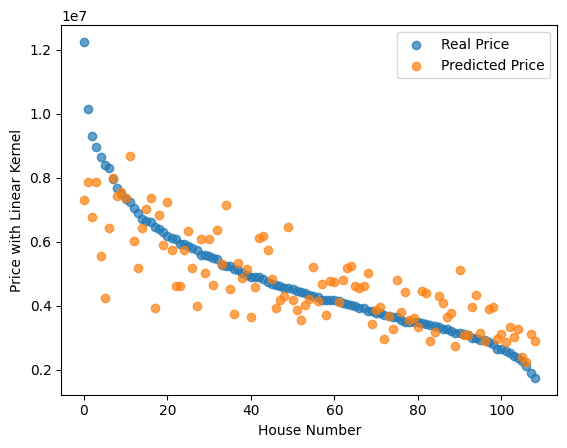

Final Cost Poly:  1020644471750.9489
Final R2 Poly: 0.4109242486564192


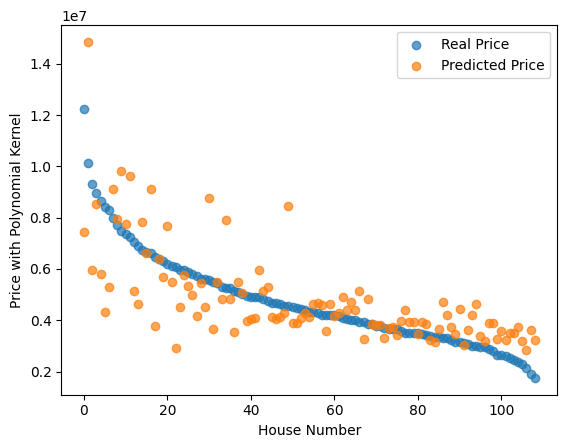

Final Cost RBF:  693286374047.324
Final R2 RBF: 0.5998624369291161


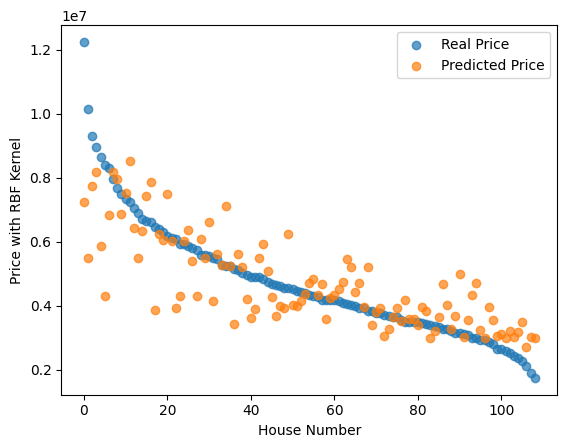

Final Cost Sigmoid:  4756161620311.027
Final R2 Sigmoid: -1.745068980964298


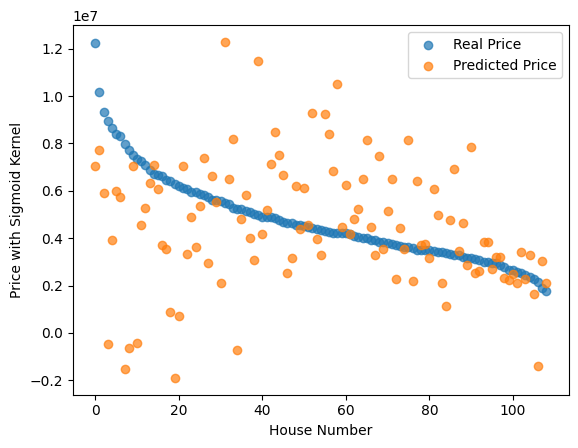

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random as rnd
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import ConfusionMatrixDisplay

def cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res))
def r_2_function(res, y):
  mean = [np.mean(y)] * len(y)
  return 1 - (cost_function(res, y)/cost_function(mean, y))

filepath = "/content/Housing.csv"

df = pd.read_csv(filepath)

scaler_X = StandardScaler() # Scaler for input features
scaler_Y = StandardScaler() # Scaler for output features

y = df.values[:, 0]

paramnames = df.columns.values[:]
params = np.zeros(len(df.values[0]))
inputdata = df.values[:, 1:-1]

for i in range(len(inputdata)):
  for j in range(len(inputdata[i])):
    if inputdata[i][j] == "yes":
      inputdata[i][j] = 1
    elif inputdata[i][j] == "no":
      inputdata[i][j] = 0
inputdata = np.array(inputdata)
inputdata = scaler_X.fit_transform(inputdata) # Fit and transform input features

validation_indices = np.arange(rnd.randint(0, 4), len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

y = np.array(y)
y = y.reshape(-1, 1)
y = scaler_Y.fit_transform(y) # Fit and transform input features

result = svm.SVR(kernel="linear", epsilon=0.2).fit(inputdata, y.ravel())

final_y_values = scaler_Y.inverse_transform((result.predict(validationdata)).reshape(-1, 1)).reshape(-1)
final_cost = cost_function(final_y_values, validationy)
print("Final Cost Linear: ", final_cost)
print("Final R2 Linear:" , r_2_function(final_y_values, validationy))
plt.scatter(np.arange(len(validationy)), validationy, label='Real Price', alpha=0.7)
plt.scatter(np.arange(len(validationy)), final_y_values,  label='Predicted Price', alpha=0.7)
plt.xlabel('House Number')
plt.ylabel('Price with Linear Kernel')
plt.legend()
plt.show()

result = svm.SVR(kernel="poly", epsilon=0.2).fit(inputdata, y.ravel())

final_y_values = scaler_Y.inverse_transform((result.predict(validationdata)).reshape(-1, 1)).reshape(-1)
final_cost = cost_function(final_y_values, validationy)
print("Final Cost Poly: ", final_cost)
print("Final R2 Poly:" , r_2_function(final_y_values, validationy))
plt.scatter(np.arange(len(validationy)), validationy, label='Real Price', alpha=0.7)
plt.scatter(np.arange(len(validationy)), final_y_values,  label='Predicted Price', alpha=0.7)
plt.xlabel('House Number')
plt.ylabel('Price with Polynomial Kernel')
plt.legend()
plt.show()

result = svm.SVR(kernel="rbf", epsilon=0.2).fit(inputdata, y.ravel())

final_y_values = scaler_Y.inverse_transform((result.predict(validationdata)).reshape(-1, 1)).reshape(-1)
final_cost = cost_function(final_y_values, validationy)
print("Final Cost RBF: ", final_cost)
print("Final R2 RBF:" , r_2_function(final_y_values, validationy))
plt.scatter(np.arange(len(validationy)), validationy, label='Real Price', alpha=0.7)
plt.scatter(np.arange(len(validationy)), final_y_values,  label='Predicted Price', alpha=0.7)
plt.xlabel('House Number')
plt.ylabel('Price with RBF Kernel')
plt.legend()
plt.show()

result = svm.SVR(kernel="sigmoid", epsilon=0.2).fit(inputdata, y.ravel())

final_y_values = scaler_Y.inverse_transform((result.predict(validationdata)).reshape(-1, 1)).reshape(-1)
final_cost = cost_function(final_y_values, validationy)
print("Final Cost Sigmoid: ", final_cost)
print("Final R2 Sigmoid:" , r_2_function(final_y_values, validationy))
plt.scatter(np.arange(len(validationy)), validationy, label='Real Price', alpha=0.7)
plt.scatter(np.arange(len(validationy)), final_y_values,  label='Predicted Price', alpha=0.7)
plt.xlabel('House Number')
plt.ylabel('Price with Sigmoid Kernel')
plt.legend()
plt.show()